# DSM050 Coursework 2 — Socio-Economic Influences on Life Expectancy Outcome - Botswana (Jupyter notebooks)

**Focus country:** Botswana  
**Datasets (provided):**  

### Data from Kaggle datasets
    - Life expectancy (%) — `life_expectancy_by_birth.csv`  
    - GNI per capita - `gross_national_income_per_capital.csv`
    - Hu Development Index - `human_development_index.csv`

### Data from World Bank datasets
    - Literacy, Rate % — `literacy_rate_data.csv`

### Data from SASSCAL Bank datasets
    - SADC Countries, coordinate geometries — `southern_africa_data.csv`
---

## 1. Objective(s)

This study evaluates Botswana’s life expectancy, explores how socio-economic factors influence it, compares five-year regional averages across SADC countries, and proposes targeted interventions to improve outcomes.

## 2.  Objectives (SMART)
    - Data preparation (reproducible): Convert both pivot-style CSV exports into tidy long-form data (`year`, `country`, `indicator`, `value`) with validation checks and documented handling of missing values.
    - Load the tidy dataset into SQLite for data analytics, and produce at least 5 SQL-derived summaries that compare Botswana to regional benchmarks (mean, median, rank, trend).
    - Visualise Botswana’s trend vs the SADC distribution for each indicator, and compute effect sizes (Botswana minus regional mean).
    - Modelling (advanced): Train and evaluate at least two models:
    - Regression: predict life expectancy using GNI per capita, year, and country effects.
    - Classification: predict whether a country-year is high life expectancy (≥80%) from GNI per capita + year.
    - Use robust validation, metrics, and interpretation.
    - Create a dashboard for `quick overview of Botswana statistics` (e.g. life expectancy trend, Literacy rate, GNI trend, human development index, etc.)
    - Critical evaluation: Discuss limitations (aggregation level, missingness, comparability), ethical considerations, and practical implications for Botswana.

 Note: These are country-level indicators. Findings should be interpreted as macro/sector signals, not individual-level causal effects.

## 3. Research Question(s)
    - How have `Botswana’s life expectancy by birth` changed over the years?
    - How does Botswana life expectancy by birth `compare` with its regional peers, SADC?
    - How have Botswana’s `GNI per capita` changed over the years?
    - How have Botswana’s `Literacy rate` changed over the years?
    - How have Botswana’s `Human Development Index` changed over the years?
    - How is life expectancy `influenced` by GNI per capita?
    - How is life expectancy `influenced` by Literacy rate?
    - How is life expectancy `influenced` by Human Development Index?



## 4. Data loading and tidy transformation

### 4.1 Check the current work directory

In [1]:
from pathlib import Path

print("Current folder:", Path.cwd())

Current folder: /home/a5732212-dcc7-4e23-8671-1d911162392f/DSM050-Data Viz/Course Work 2-Copy1


### 4.2 List all the files in the current directory

In [2]:
for file in Path.cwd().iterdir():
    print(file.name)

merged_geo_socio_data.csv
southern_africa_proj.dbf
dsm_050_cw2.ipynb
gross_national_income_per_capital.csv
consolidated_indicators.csv
human_development_index.csv
literacy_rate_data.csv
southern_africa_proj.shx
southern_africa_proj.prj
southern_africa_proj.shp
southern_africa_data.csv
.ipynb_checkpoints
life_expectancy_by_birth.csv
merged_southern_africa_data.csv


### 4.3 Load the file paths and display the first 5 rows of each data set

#### `to display the first 5 rows: data_frame.head()`

In [3]:
from pathlib import Path
import re

import pandas as pd
from IPython.display import display


# 1. Configuration

folder_path = Path(".")
output_file = "consolidated_indicators.csv"

# Columns to remove from every source dataset
columns_to_drop = ["hdi_rank_2021", "hdicode", "region"]

# Columns used to merge the datasets
merge_columns = ["Country", "Year"]


# 2. Locate CSV files

csv_files = sorted(
    file_path
    for file_path in folder_path.glob("*.csv")
    if file_path.name != output_file
)

if not csv_files:
    raise FileNotFoundError(
        f"No source CSV files were found in: {folder_path.resolve()}"
    )


In [7]:
# 3. Function to read CSV files

def read_csv_flexible(file_path):
    """
    Attempt to read a CSV file using comma, semicolon,
    or tab separators and alternative encodings.
    """

    separators = [",", ";", "\t"]
    encodings = ["utf-8-sig", "utf-8", "latin-1"]

    last_error = None

    for encoding in encodings:
        for separator in separators:
            try:
                candidate_df = pd.read_csv(
                    file_path,
                    sep=separator,
                    encoding=encoding,
                    on_bad_lines="warn"
                )

                # A wrong separator commonly produces only one column
                if candidate_df.shape[1] > 1:
                    return candidate_df, separator, encoding

            except Exception as error:
                last_error = error

    raise RuntimeError(
        f"Could not read {file_path.name}: {last_error}"
    )




In [8]:
# 4. Process each CSV file

processed_dataframes = []


for file_path in csv_files:

    # Use the filename without .csv as the indicator name
    indicator = file_path.stem

    print("=" * 80)
    print(f"FILE: {file_path.name}")
    print(f"Indicator: {indicator}")

    # Read the file

    try:
        df, separator_used, encoding_used = read_csv_flexible(file_path)

    except Exception as error:
        print(f"Skipped {file_path.name}: {error}")
        continue

    print(f"Separator used: {repr(separator_used)}")
    print(f"Encoding used: {encoding_used}")
    
    # Clean column names

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    # Standardise common column names
    rename_columns = {}

    for column in df.columns:

        normalised_name = (
            str(column)
            .strip()
            .lower()
            .replace("_", " ")
        )

        if normalised_name in ["country", "country name"]:
            rename_columns[column] = "Country"

        elif normalised_name in ["year", "date year"]:
            rename_columns[column] = "Year"

    df = df.rename(columns=rename_columns)

    # Drop selected columns

    existing_columns_to_drop = [
        column
        for column in columns_to_drop
        if column in df.columns
    ]

    df = df.drop(columns=columns_to_drop, errors="ignore")

    if existing_columns_to_drop:
        print(
            "Columns removed:",
            existing_columns_to_drop
        )

    print(
        f"Source shape: {df.shape[0]:,} rows × "
        f"{df.shape[1]} columns"
    )

    display(df.head())
    
    # Identify wide-format year columns

    year_columns = [
        column
        for column in df.columns
        if re.search(
            r"(?:19|20)\d{2}$",
            str(column)
        )
    ]

    # Case 1: Wide-format dataset

    if year_columns:

        melted_df = pd.melt(df, id_vars=["Country"],
            value_vars=year_columns,
            var_name="Year",
            value_name=indicator
        )

        print("Dataset format: wide")
        
    # Case 2: Dataset already in long format

    elif "Year" in df.columns:

        possible_value_columns = [
            indicator,
            "Value",
            "value",
            "Literacy rate",
            "Literacy Rate",
            "literacy_rate",
            "Literacy",
            "literacy"
        ]

        value_column = next(
            (
                column
                for column in possible_value_columns
                if column in df.columns
            ),
            None
        )

        # Search remaining columns if a standard value name
        # was not found
        if value_column is None:

            excluded_columns = {"Country", "Year"}

            candidate_columns = [column
                for column in df.columns
                if column not in excluded_columns
            ]

            # Select the column with the highest proportion
            # of numeric values
            numeric_scores = {}

            for column in candidate_columns:

                numeric_values = pd.to_numeric(df[column]
                    .astype(str)
                    .str.replace(",", "", regex=False),
                    errors="coerce"
                )

                numeric_scores[column] = (numeric_values.notna().mean())

            if numeric_scores:

                best_candidate = max(numeric_scores, key=numeric_scores.get)

                if numeric_scores[best_candidate] > 0:
                    value_column = best_candidate

        if value_column is None:
            print(
                f"Skipped {file_path.name}: "
                "the indicator-value column could not be identified."
            )
            print("Available columns:", df.columns.tolist())
            continue

        print("Dataset format: long")
        print(f"Value column selected: {value_column}")

        melted_df = df[["Country", "Year", value_column]].copy()

        melted_df = melted_df.rename(columns={value_column: indicator})

    # Case 3: Dataset contains no recognisable year

    else:

        print(
            f"Skipped {file_path.name}: "
            "no year columns or Year column were found."
        )

        print("Available columns:", df.columns.tolist())
        continue

    # Clean Year

    melted_df["Year"] = (melted_df["Year"]
        .astype(str)
        .str.extract(
            r"((?:19|20)\d{2})",
            expand=False
        )
    )

    # Remove records without a valid year
    melted_df = melted_df.dropna(subset=["Year"])

    # Convert Year to integer
    melted_df["Year"] = (melted_df["Year"]
        .astype(int)
    )

    # Clean the indicator values

    melted_df[indicator] = pd.to_numeric(melted_df[indicator]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

    # Remove records without an indicator value
    melted_df = melted_df.dropna(subset=[indicator])

    melted_df["Country"] = (melted_df["Country"]
        .astype("string")
        .str.strip()
    )

    # Rename country names for consistency
    # Standardise country names

    country_name_mapping = {
        "Bahamas, The": "Bahamas",
        "Bolivia (Plurinational State of)": "Bolivia",
        "Bolivia, Plurinational State of": "Bolivia",
        "Brunei Darussalam": "Brunei",
        "Cabo Verde": "Cape Verde",
        "Congo": "Democratic Republic of the Congo",
        "Congo, Rep.": "Democratic Republic of the Congo",
        "Congo (Democratic Republic of the)": "Democratic Republic of the Congo",
        "Congo, Dem. Rep.": "Democratic Republic of the Congo",
        "Democratic Republic of Congo": "Democratic Republic of the Congo",
        "Côte d’Ivoire": "Cote d'Ivoire",
        "Côte d'Ivoire": "Cote d'Ivoire",
        "Egypt, Arab Rep.": "Egypt",
        "Gambia, The": "Gambia",
        "Hong Kong SAR, China": "Hong Kong",
        "Iran (Islamic Republic of)": "Iran",
        "Iran, Islamic Rep.": "Iran",
        "Korea (Republic of)": "South Korea",
        "Korea, Rep.": "South Korea",
        "Republic of Korea": "South Korea",
        "Korea (Democratic People's Rep. of)": "North Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Lao People's Democratic Republic": "Laos",
        "Lao PDR": "Laos",
        "Micronesia (Federated States of)": "Micronesia",
        "Micronesia, Fed. Sts.": "Micronesia",
        "Moldova (Republic of)": "Moldova",
        "Russian Federation": "Russia",
        "Slovak Republic": "Slovakia",
        "Syrian Arab Republic": "Syria",
        "Swaziland": "Eswatini",
        "Kingdom of Eswatini": "Eswatini",
        "eSwatini": "Eswatini",
        "Tanzania (United Republic of)": "Tanzania",
        "Türkiye": "Turkey",
        "United States of America": "United States",
        "United States of America (the)": "United States",
        "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
        "Venezuela (Bolivarian Republic of)": "Venezuela",
        "Venezuela, RB": "Venezuela",
        "Viet Nam": "Vietnam",
        "Yemen, Rep.": "Yemen"
    }

    melted_df["Country"] = (melted_df["Country"]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace(country_name_mapping)
    )
    
    # Remove duplicate country-year-indicator records
    # --------------------------------------------------------

    original_rows = len(melted_df)

    melted_df = melted_df.drop_duplicates(
        subset=["Country", "Year", indicator]
    )

    exact_duplicates_removed = (
        original_rows - len(melted_df)
    )

    if exact_duplicates_removed > 0:
        print(
            f"Removed {exact_duplicates_removed:,} "
            "exact duplicate records."
        )

    # --------------------------------------------------------
    # Check for conflicting values
    # --------------------------------------------------------

    conflict_summary = (melted_df
        .groupby(["Country", "Year"],dropna=False)[indicator]
        .nunique(dropna=True)
        .reset_index(
            name="Unique_Value_Count"
        )
    )

    conflicting_keys = conflict_summary[
        conflict_summary["Unique_Value_Count"] > 1
    ]

    if not conflicting_keys.empty:

        print(
            f"Warning: {len(conflicting_keys):,} "
            "country-year records contain conflicting values."
        )

        conflicting_rows = melted_df.merge(
            conflicting_keys[["Country", "Year"]], on=["Country", "Year"], how="inner"
        )

        display(conflicting_rows.head(20))

        print(
            "The first non-null value will be retained."
        )

    # --------------------------------------------------------
    # Consolidate remaining duplicate keys
    # --------------------------------------------------------

    melted_df = (melted_df
        .groupby(["Country", "Year"], dropna=False, as_index=False)
        .agg({indicator: "first"})
    )

    melted_df = melted_df[
        ["Country", "Year", indicator]
    ]

    melted_df = melted_df.reset_index(drop=True)

    print(
        f"Processed shape: {melted_df.shape[0]:,} rows × "
        f"{melted_df.shape[1]} columns"
    )

    print(
        f"Non-null {indicator} values: "
        f"{melted_df[indicator].notna().sum():,}"
    )

    display(melted_df.head())

    processed_dataframes.append(melted_df)




FILE: gross_national_income_per_capital.csv
Indicator: gross_national_income_per_capital
Separator used: ','
Encoding used: utf-8-sig
Columns removed: ['hdi_rank_2021', 'hdicode', 'region']
Source shape: 206 rows × 34 columns


,ISO3,Country,gnipc_1990,gnipc_1991,gnipc_1992,gnipc_1993,gnipc_1994,gnipc_1995,gnipc_1996,gnipc_1997,...,gnipc_2012,gnipc_2013,gnipc_2014,gnipc_2015,gnipc_2016,gnipc_2017,gnipc_2018,gnipc_2019,gnipc_2020,gnipc_2021
0,AFG,Afghanistan,2684.550019,2276.289409,2059.868084,1525.533426,1087.961890,1339.087122,1332.307210,1230.261290,...,2125.862821,2193.553936,2178.507021,2101.589319,2077.566899,2085.487571,2054.939895,2097.889450,1997.852149,1824.190915
1,AGO,Angola,4845.706901,5405.349257,2073.902390,2034.215197,1557.198363,3411.906930,3372.994265,3980.795390,...,7280.845666,7478.104777,7704.231949,7652.656486,7189.426672,6861.575738,6381.521946,6082.746624,5593.142060,5465.617791
2,ALB,Albania,4742.215529,3358.087827,3080.746654,3538.885493,3940.312045,4583.051036,5044.975175,4496.163681,...,11146.263030,11552.982470,11691.648290,12016.297600,12484.624200,12802.148310,13302.705960,13485.311240,12996.762910,14131.110390
3,AND,Andorra,43773.146500,43175.147600,41935.787200,40085.315890,39923.545880,40270.767900,41014.578790,44756.595970,...,47126.814610,46385.095200,48483.720320,49936.874540,52267.738320,52650.225760,53483.306630,54465.047400,47878.666640,51166.626610
4,ARE,United Arab Emirates,102433.136000,96250.290360,93043.477370,92505.331100,96784.426940,101303.275800,101490.243900,103567.035300,...,57445.954750,60005.695360,62573.505310,65577.512240,66881.329740,67667.508460,67195.095230,68590.900940,63016.401220,62573.591810


Dataset format: wide


,Country,Year,gross_national_income_per_capital
0,Democratic Republic of the Congo,1990,1693.088418
1,Democratic Republic of the Congo,1990,4373.460798
2,Democratic Republic of the Congo,1991,1495.463703
3,Democratic Republic of the Congo,1991,4406.928262
4,Democratic Republic of the Congo,1992,1283.041894
5,Democratic Republic of the Congo,1992,4511.057681
6,Democratic Republic of the Congo,1993,1098.405542
7,Democratic Republic of the Congo,1993,4132.073586
8,Democratic Republic of the Congo,1994,954.170257
9,Democratic Republic of the Congo,1994,3903.762345


The first non-null value will be retained.
Processed shape: 6,428 rows × 3 columns
Non-null gross_national_income_per_capital values: 6,428


...

Dataset format: long
Value column selected: life_expectancy_by_birth
Removed 64 exact duplicate records.
Processed shape: 6,560 rows × 3 columns
Non-null merged_southern_africa_data values: 6,560


,Country,Year,merged_southern_africa_data
0,Afghanistan,1990,45.9672
1,Afghanistan,1991,46.6631
2,Afghanistan,1992,47.5955
3,Afghanistan,1993,51.4664
4,Afghanistan,1994,51.4945


FILE: southern_africa_data.csv
Indicator: southern_africa_data
Separator used: ','
Encoding used: utf-8-sig
Source shape: 14 rows × 2 columns


,Country,geometry
0,Zambia,"POLYGON ((1581593.430223649 9077604.280322867,..."
1,Malawi,"POLYGON ((1821541.5243932286 8937997.83813876,..."
2,Zimbabwe,"POLYGON ((952921.3266034896 8026895.859590087,..."
3,Botswana,POLYGON ((951501.2412112369 8028147.4859734755...
4,Swaziland,"POLYGON ((1603701.416387874 7082957.905367061,..."


Skipped southern_africa_data.csv: no year columns or Year column were found.
Available columns: ['Country', 'geometry']


In [9]:
# 5. Confirm files were successfully processed

if not processed_dataframes:
    raise RuntimeError(
        "None of the CSV files were successfully processed."
    )


# 6. Consolidate all indicators

consolidated_df = processed_dataframes[0]


for current_df in processed_dataframes[1:]:

    consolidated_df = consolidated_df.merge(current_df, on = merge_columns, how="outer", suffixes=("", "_new"), validate="one_to_one")

    # Combine Country values from both datasets
    if "Country_new" in consolidated_df.columns:

        consolidated_df["Country"] = (
            consolidated_df["Country"]
            .combine_first(
                consolidated_df["Country_new"]
            )
        )

        consolidated_df = consolidated_df.drop(
            columns=["Country_new"]
        )




In [10]:
# 7. Arrange, sort and clean the final dataset

indicator_columns = [
    column
    for column in consolidated_df.columns
    if column not in ["Country", "Year"]
]

consolidated_df = consolidated_df[
    ["Country", "Year"] + indicator_columns
]

consolidated_df = (consolidated_df
    .sort_values(by = ["Country","Year"], na_position="last")
    .reset_index(drop=True)
)




In [11]:
# 8. Display the final result

print("=" * 80)
print("FINAL CONSOLIDATED DATASET")

print(
    f"Final shape: {consolidated_df.shape[0]:,} rows × "
    f"{consolidated_df.shape[1]} columns"
)

print("\nNon-null values by indicator:")

display(consolidated_df[indicator_columns]
    .notna()
    .sum()
    .rename("Non-null values")
    .to_frame()
)

display(consolidated_df.head())



FINAL CONSOLIDATED DATASET
Final shape: 8,456 rows × 8 columns

Non-null values by indicator:


,Non-null values
gross_national_income_per_capital,6428
human_development_index,5891
life_expectancy_by_birth,6560
literacy_rate_data,2984
merged_geo_socio_data,6560
merged_southern_africa_data,6560


,Country,Year,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data
0,Afghanistan,1979,NaN,NaN,NaN,11.1428,NaN,NaN
1,Afghanistan,1990,2684.550019,0.273,45.9672,NaN,45.9672,45.9672
2,Afghanistan,1991,2276.289409,0.279,46.6631,NaN,46.6631,46.6631
3,Afghanistan,1992,2059.868084,0.287,47.5955,NaN,47.5955,47.5955
4,Afghanistan,1993,1525.533426,0.297,51.4664,NaN,51.4664,51.4664


In [12]:
# 9. Save consolidated dataset

consolidated_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(
    f"\nSaved consolidated dataset as: "
    f"{output_file}"
)


Saved consolidated dataset as: consolidated_indicators.csv


## 5. Exploratory Data Analysis

### 5.1 Global Statistics

In [13]:
# Generate subset from the global dataset Year >= 2005
global_subset=(consolidated_df
    .loc[lambda df_: df_["Year"]>=2005]
    .copy()
              )

# Display global_subset
print("=" * 80)
print("GLOBAL SUBSET DATA")

print(
    f"Final shape: {global_subset.shape[0]:,} rows × "
    f"{global_subset.shape[1]} columns"
)

display(global_subset.head())


GLOBAL SUBSET DATA
Final shape: 4,264 rows × 8 columns


,Country,Year,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data
16,Afghanistan,2005,1435.191730,0.400,58.3608,NaN,58.3608,58.3608
17,Afghanistan,2006,1518.767846,0.409,58.6844,NaN,58.6844,58.6844
18,Afghanistan,2007,1811.166659,0.424,59.1113,NaN,59.1113,59.1113
19,Afghanistan,2008,1753.066993,0.430,59.8515,NaN,59.8515,59.8515
20,Afghanistan,2009,1884.200863,0.440,60.3636,NaN,60.3636,60.3636


In [14]:
# Generate descriptive statistics for the global dataset

global_subset_summary=(global_subset
    .copy()
    .drop(["Year"], axis=1)
    .describe()
                      )

# Display the descriptive statistics of the global subset data
print("=" * 80)
print("DESCRIPTIVE STATISTICS FOR GLOBAL SUBSET DATA")

print(
    f"Final shape: {global_subset_summary.shape[0]:,} rows × "
    f"{global_subset_summary.shape[1]} columns"
)

display(global_subset_summary)

DESCRIPTIVE STATISTICS FOR GLOBAL SUBSET DATA
Final shape: 8 rows × 6 columns


,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data
count,3448.000000,3386.000000,3485.000000,1568.000000,3485.000000,3485.000000
mean,18550.779899,0.700206,70.703872,86.646286,70.703872,70.703872
std,20105.153774,0.153639,8.428735,16.582000,8.428735,8.428735
min,731.786709,0.298000,42.125400,11.170000,42.125400,42.125400
25%,4191.308688,0.581000,64.966600,77.214975,64.966600,64.966600
50%,11560.070945,0.722000,72.248800,94.856297,72.248800,72.248800
75%,24991.905123,0.817000,76.936000,98.999605,76.936000,76.936000
max,146829.700600,0.962000,86.542400,100.000000,86.542400,86.542400


### 5.2 Botswana Statistics

In [15]:
# Create dataframe for Botswana dataset
botswana_df = (consolidated_df
    .loc[lambda df_: (df_["Country"] == "Botswana") & (df_["Year"]>= 2005)]
              )

print(
    f"Final shape: {botswana_df.shape[0]:,} rows × "
    f"{botswana_df.shape[1]} columns"
)

display(botswana_df.head())

Final shape: 17 rows × 8 columns


,Country,Year,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data
890,Botswana,2005,10776.31728,0.604,52.6104,NaN,52.6104,52.6104
891,Botswana,2006,11501.98728,0.618,53.9182,NaN,53.9182,53.9182
892,Botswana,2007,12301.25885,0.632,55.7320,NaN,55.7320,55.7320
893,Botswana,2008,12863.84465,0.642,57.1206,NaN,57.1206,57.1206
894,Botswana,2009,12064.50597,0.647,58.2791,NaN,58.2791,58.2791


In [16]:
# Generate descriptive statistics for Botswana dataset
(botswana_df
    .drop(["Year"], axis=1)
    .describe()
     .round(2)
)


,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data
count,17.00,17.00,17.00,1.00,17.00,17.00
mean,14198.05,0.68,61.02,99.14,61.02,61.02
std,1889.60,0.04,4.31,NaN,4.31,4.31
min,10776.32,0.60,52.61,99.14,52.61,52.61
25%,12580.34,0.65,58.28,99.14,58.28,58.28
50%,14696.03,0.69,61.14,99.14,61.14,61.14
75%,16144.88,0.71,65.42,99.14,65.42,65.42
max,16308.09,0.72,66.75,99.14,66.75,66.75


### 5.3 How have Botswana’s life expectancy by birth changed over the years?

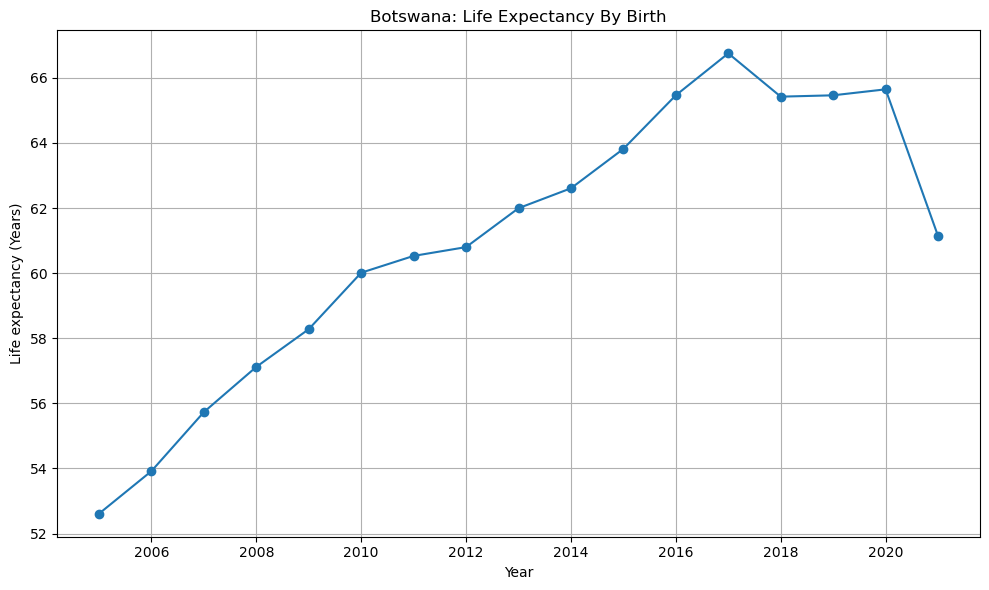

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Select indicator
indicator = "life_expectancy_by_birth"

# Remove missing values and sort by year
plot_df = (botswana_df
    .dropna(subset=["Year", indicator])
    .sort_values("Year")
    .loc[lambda df_: df_["Year"]>= 2005]
          )

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(plot_df["Year"], plot_df[indicator], marker="o")

ax.set_title(f"Botswana: {indicator.replace('_', ' ').title()}")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (Years)")
ax.grid(True)

plt.tight_layout()
plt.show()

### 5.4 How does Botswana life expectancy by birth compare with its regional peers, SADC?

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# SADC countries
sadc_country_rows = [
    "Angola",
    "Botswana",
    "Comoros",
    "Democratic Republic of the Congo",
    "Eswatini",
    "Lesotho",
    "Madagascar",
    "Malawi",
    "Mauritius",
    "Mozambique",
    "Namibia",
    "Seychelles",
    "South Africa",
    "Tanzania",
    "Zambia",
    "Zimbabwe",
]

# Selected Developed countries for comparison purposes
developed_country_rows = [
    "Australia",
    "Botswana",
    "Belgium",
    "Canada",
    "France",
    "Germany",
    "Italy",
    "Netherlands",
    "Spain",
    "Sweden",
    "Switzerland",
    "United Kingdom",
    "United States"
]



In [19]:
# Function to prepare heatmap data
def get_heatmap_data(country_list):
    mean_profile_per_country = (
        consolidated_df[
            (consolidated_df["Year"] >= 2005) &
            (consolidated_df["Country"].isin(country_list))
        ]
        .groupby("Country")["life_expectancy_by_birth"]
        .mean()
        .dropna()
        .sort_values(ascending=False)
    )
    
    return mean_profile_per_country.to_frame(
        name="Mean Life Expectancy"
    )



In [20]:
# Prepare data
sadc_heatmap_data = get_heatmap_data(sadc_country_rows)
developed_heatmap_data = get_heatmap_data(developed_country_rows)



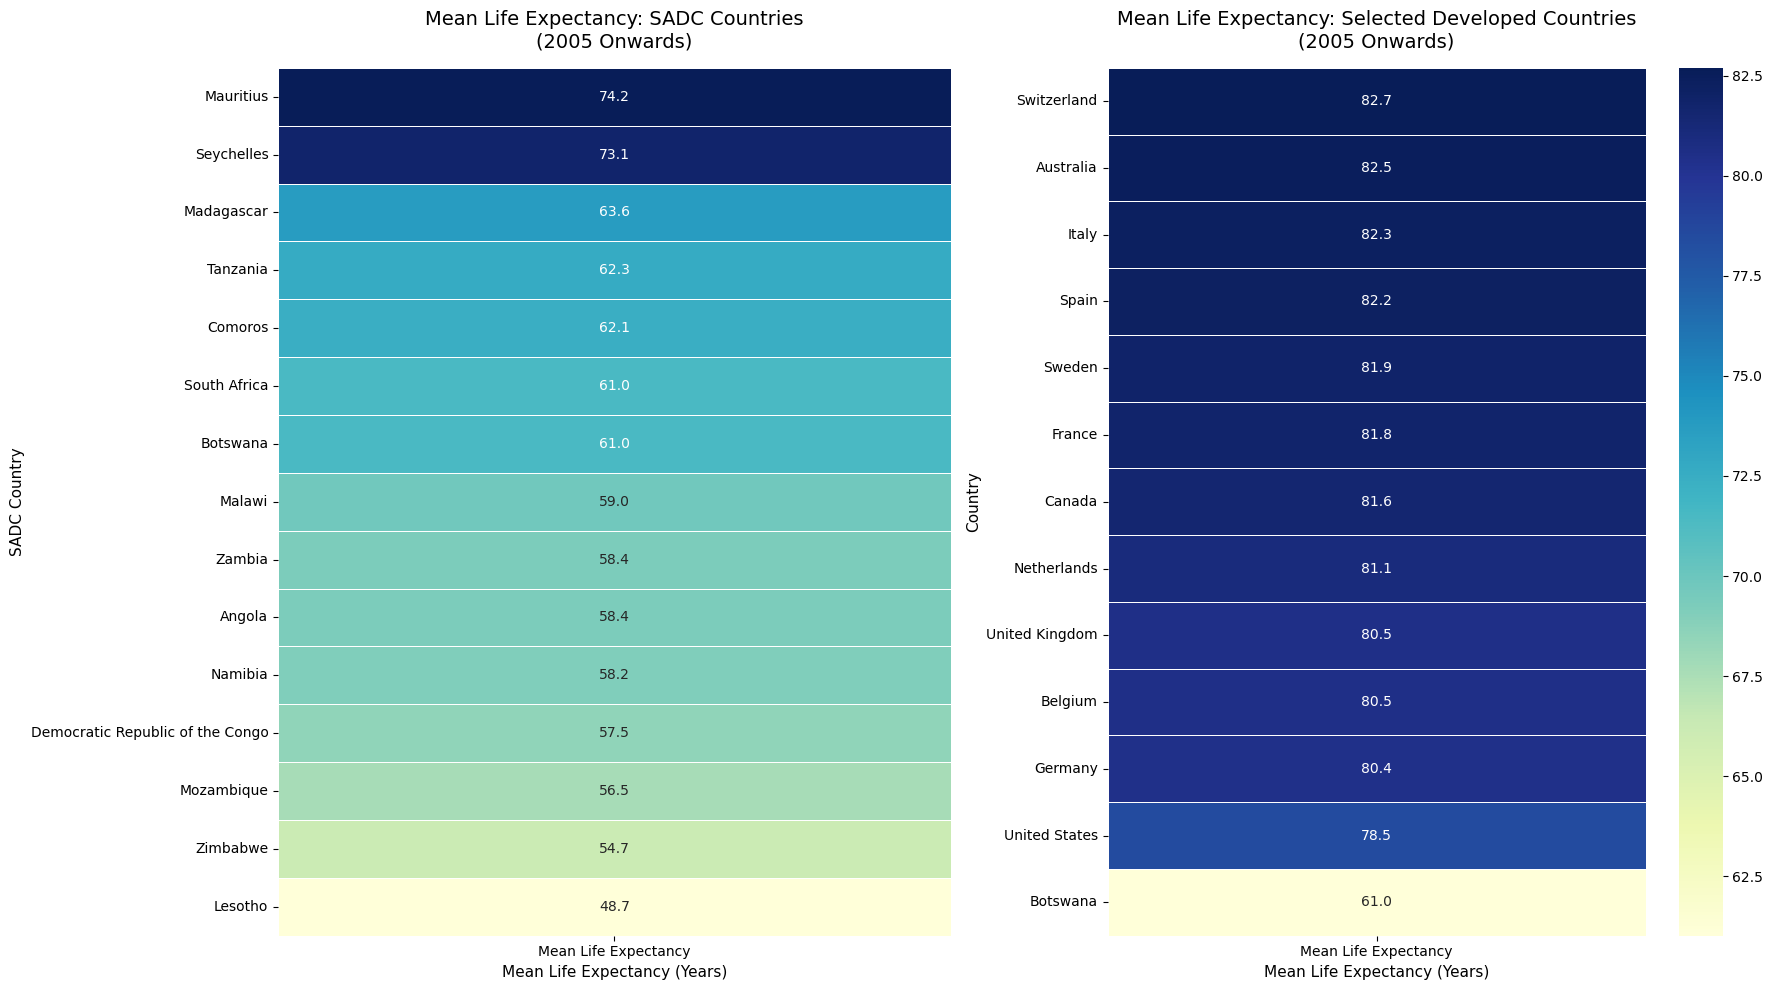

In [21]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Heat map 1: SADC
sns.heatmap(
    sadc_heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("Mean Life Expectancy: SADC Countries\n(2005 Onwards)", fontsize=14, pad=15)
axes[0].set_xlabel("Mean Life Expectancy (Years)", fontsize=11)
axes[0].set_ylabel("SADC Country", fontsize=11)

# Heat map 2: Developed countries
sns.heatmap(
    developed_heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    ax=axes[1]
)

axes[1].set_title("Mean Life Expectancy: Selected Developed Countries\n(2005 Onwards)", fontsize=14, pad=15)
axes[1].set_xlabel("Mean Life Expectancy (Years)", fontsize=11)
axes[1].set_ylabel("Country", fontsize=11)

plt.tight_layout()
plt.show()

### 5.5 How have Botswana’s GNI per capita changed over the years?

In [22]:
print(botswana_df.columns.tolist())

['Country', 'Year', 'gross_national_income_per_capital', 'human_development_index', 'life_expectancy_by_birth', 'literacy_rate_data', 'merged_geo_socio_data', 'merged_southern_africa_data']


In [23]:
import numpy as np

# Select indicator
indicator = "gross_national_income_per_capital"

# Calculate the natural logarithm of GNI per capita
# Gross National Income per Capita normally has a positively skewed distribution
# because a small number of countries have substantially higher incomes than the majority.
# A logarithmic transformation was therefore created:The addition of one allows the transformation to handle possible zero values.

botswana_subset=(botswana_df
    .copy()
    .loc[lambda df_: df_["Year"]>= 2005]
    .assign(log_gni_per_capita=lambda df_: np.log1p(df_[indicator]))
)

# Check if the column has been added correctly to new DataFrame
print(botswana_subset.columns.tolist())

['Country', 'Year', 'gross_national_income_per_capital', 'human_development_index', 'life_expectancy_by_birth', 'literacy_rate_data', 'merged_geo_socio_data', 'merged_southern_africa_data', 'log_gni_per_capita']


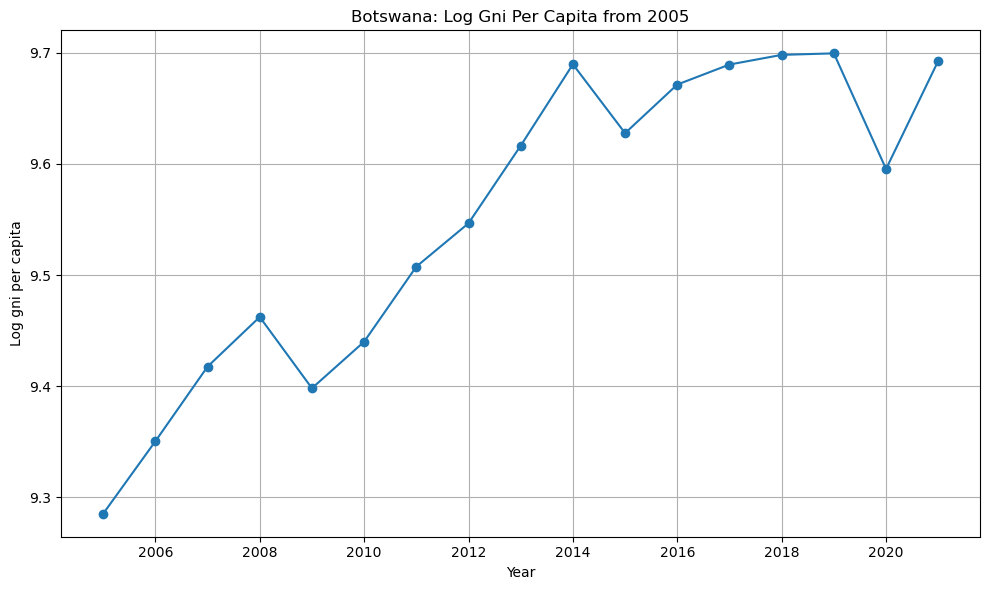

In [24]:
# Select indicator
indicator = "log_gni_per_capita"

# Plot
plot_df = botswana_subset.copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(plot_df["Year"], plot_df[indicator], marker="o")
ax.set_title(f"Botswana: {indicator.replace('_', ' ').title()} from 2005")
ax.set_xlabel("Year")
ax.set_ylabel(indicator.replace('_', ' ').capitalize())
ax.grid(True)

plt.tight_layout()
plt.show()

### 5.6 How have Botswana’s Literacy rate changed over the years?

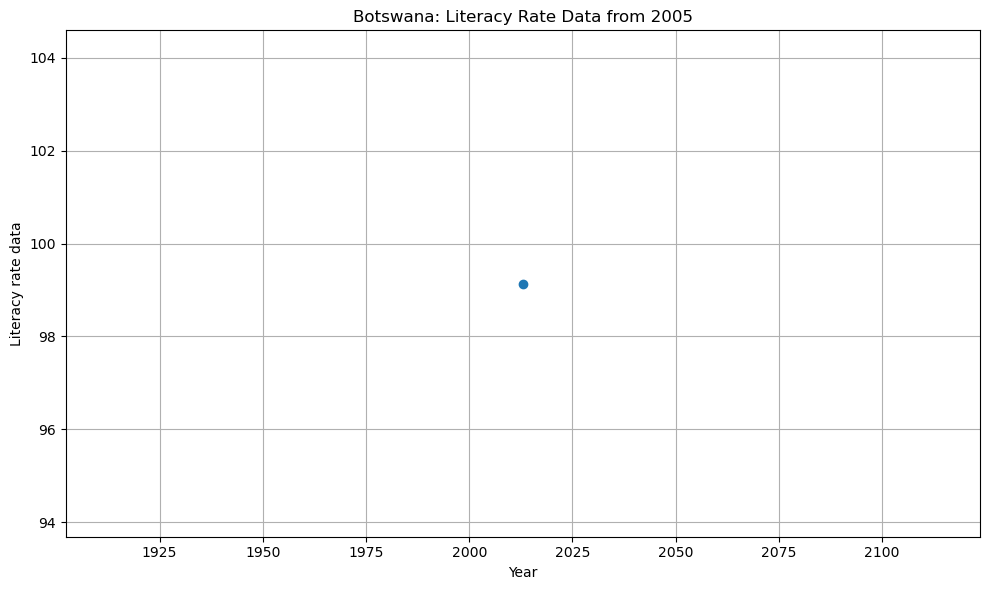

In [25]:
# Select indicator
indicator = "literacy_rate_data"

# Plot
plot_df = (botswana_subset
    .copy()
    .loc[lambda df_: df_["Year"]>= 2005]
          )

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(plot_df["Year"], plot_df[indicator], marker="o")
ax.set_title(f"Botswana: {indicator.replace('_', ' ').title()} from 2005")
ax.set_xlabel("Year")
ax.set_ylabel(indicator.replace('_', ' ').capitalize())
ax.grid(True)

plt.tight_layout()
plt.show()

### 5.7 How have Botswana’s Human Development Index changed over the years?

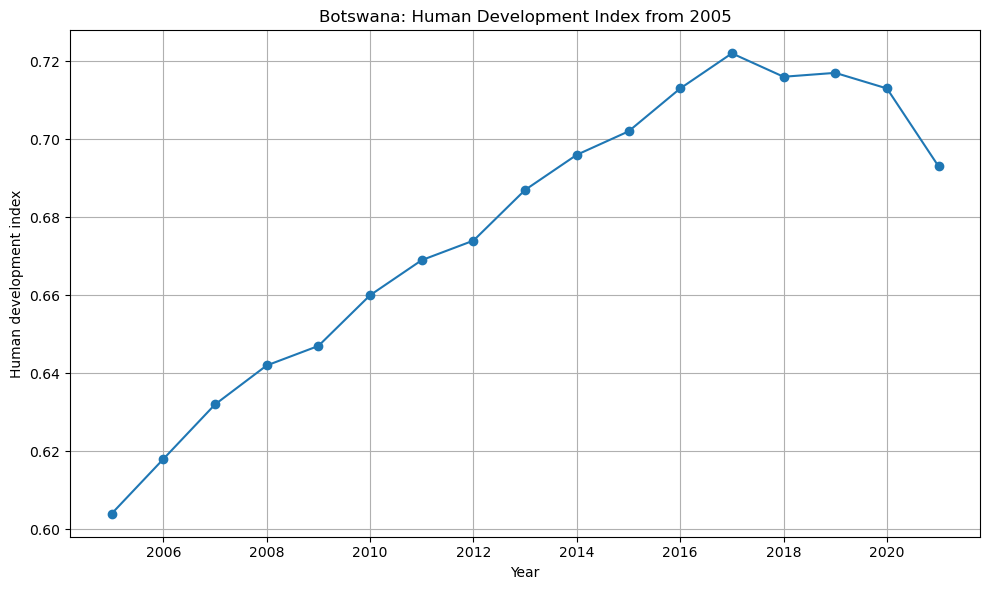

In [26]:
# Select indicator
indicator = "human_development_index"

# Plot
plot_df = (botswana_subset
    .copy()
    .loc[lambda df_: df_["Year"]>= 2005]
          )

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(plot_df["Year"], plot_df[indicator], marker="o")
ax.set_title(f"Botswana: {indicator.replace('_', ' ').title()} from 2005")
ax.set_xlabel("Year")
ax.set_ylabel(indicator.replace('_', ' ').capitalize())
ax.grid(True)

plt.tight_layout()
plt.show()

### 5.8 How is life expectancy influenced by GNI per capita?

In [27]:
botswana_subset.head()

,Country,Year,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data,log_gni_per_capita
890,Botswana,2005,10776.31728,0.604,52.6104,NaN,52.6104,52.6104,9.285199
891,Botswana,2006,11501.98728,0.618,53.9182,NaN,53.9182,53.9182,9.350362
892,Botswana,2007,12301.25885,0.632,55.7320,NaN,55.7320,55.7320,9.417538
893,Botswana,2008,12863.84465,0.642,57.1206,NaN,57.1206,57.1206,9.462254
894,Botswana,2009,12064.50597,0.647,58.2791,NaN,58.2791,58.2791,9.398106


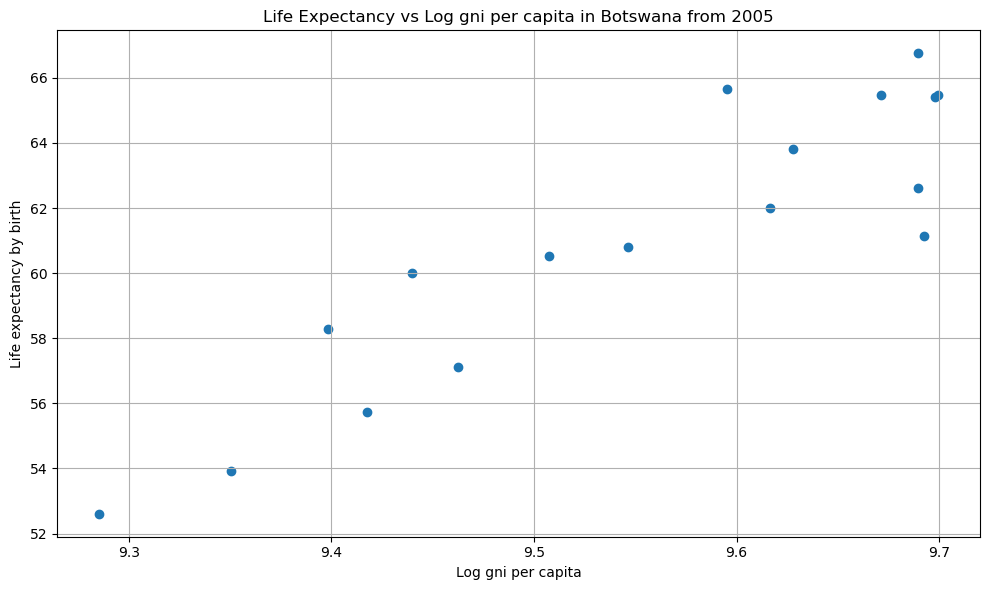

,log_gni_per_capita,life_expectancy_by_birth
log_gni_per_capita,1.000000,0.908038
life_expectancy_by_birth,0.908038,1.000000


In [28]:
# Relationship: Life Expectancy vs Gross National Income per Capita
# Select indicators
income_indicator = "log_gni_per_capita"
life_indicator = "life_expectancy_by_birth"

# Plot
plot_df = botswana_subset.copy()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df[income_indicator],
    plot_df[life_indicator]
)

plt.title(f"Life Expectancy vs {income_indicator.replace('_', ' ').capitalize()} in Botswana from 2005")
plt.xlabel(income_indicator.replace('_', ' ').capitalize())
plt.ylabel(life_indicator.replace('_', ' ').capitalize())
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate correlation using the filtered data
corr = plot_df[
    [income_indicator, life_indicator]
].corr()

display(corr)

### 5.9 How is life expectancy influenced by Literacy rate?

Not enough data set for the literacy rate for Botswana hence could not substantiate its influence on life expectancy

In [29]:
# Relationship: Life Expectancy vs literacy_rate_data
botswana_df[["Year", "literacy_rate_data"]].dropna(subset=["literacy_rate_data"])

,Year,literacy_rate_data
898,2013,99.139542


### 5.10 How is life expectancy influenced by Human Development Index?

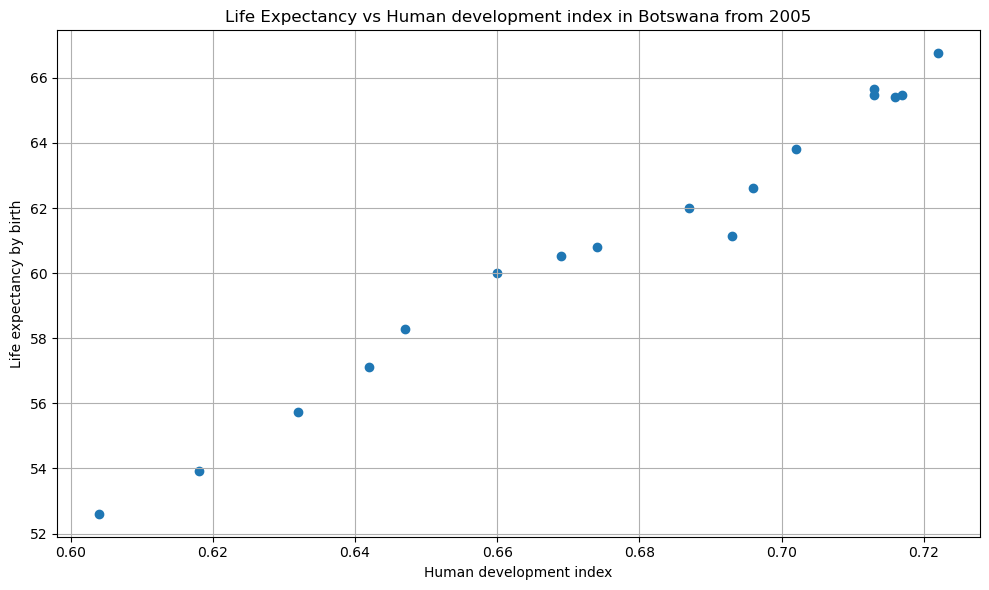

,human_development_index,life_expectancy_by_birth
human_development_index,1.000000,0.990335
life_expectancy_by_birth,0.990335,1.000000


In [30]:
# Relationship: Life Expectancy vs Human Development Index
social_indicator = "human_development_index"
life_indicator = "life_expectancy_by_birth"

# Plot
plot_df = botswana_subset.copy()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df[social_indicator],
    plot_df[life_indicator]
)

plt.title(f"Life Expectancy vs {social_indicator.replace('_', ' ').capitalize()} in Botswana from 2005")
plt.xlabel(social_indicator.replace('_', ' ').capitalize())
plt.ylabel(life_indicator.replace('_', ' ').capitalize())
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate correlation using the filtered data
corr = plot_df[
    [social_indicator, life_indicator]
].corr()

display(corr)


## 6. Dashboard

In [31]:
# Check if column "log_gni_per_capita" is still present on the subset
# If not run code from "Section 5.5" then come back to run this cell
botswana_subset.copy().head()

,Country,Year,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data,log_gni_per_capita
890,Botswana,2005,10776.31728,0.604,52.6104,NaN,52.6104,52.6104,9.285199
891,Botswana,2006,11501.98728,0.618,53.9182,NaN,53.9182,53.9182,9.350362
892,Botswana,2007,12301.25885,0.632,55.7320,NaN,55.7320,55.7320,9.417538
893,Botswana,2008,12863.84465,0.642,57.1206,NaN,57.1206,57.1206,9.462254
894,Botswana,2009,12064.50597,0.647,58.2791,NaN,58.2791,58.2791,9.398106


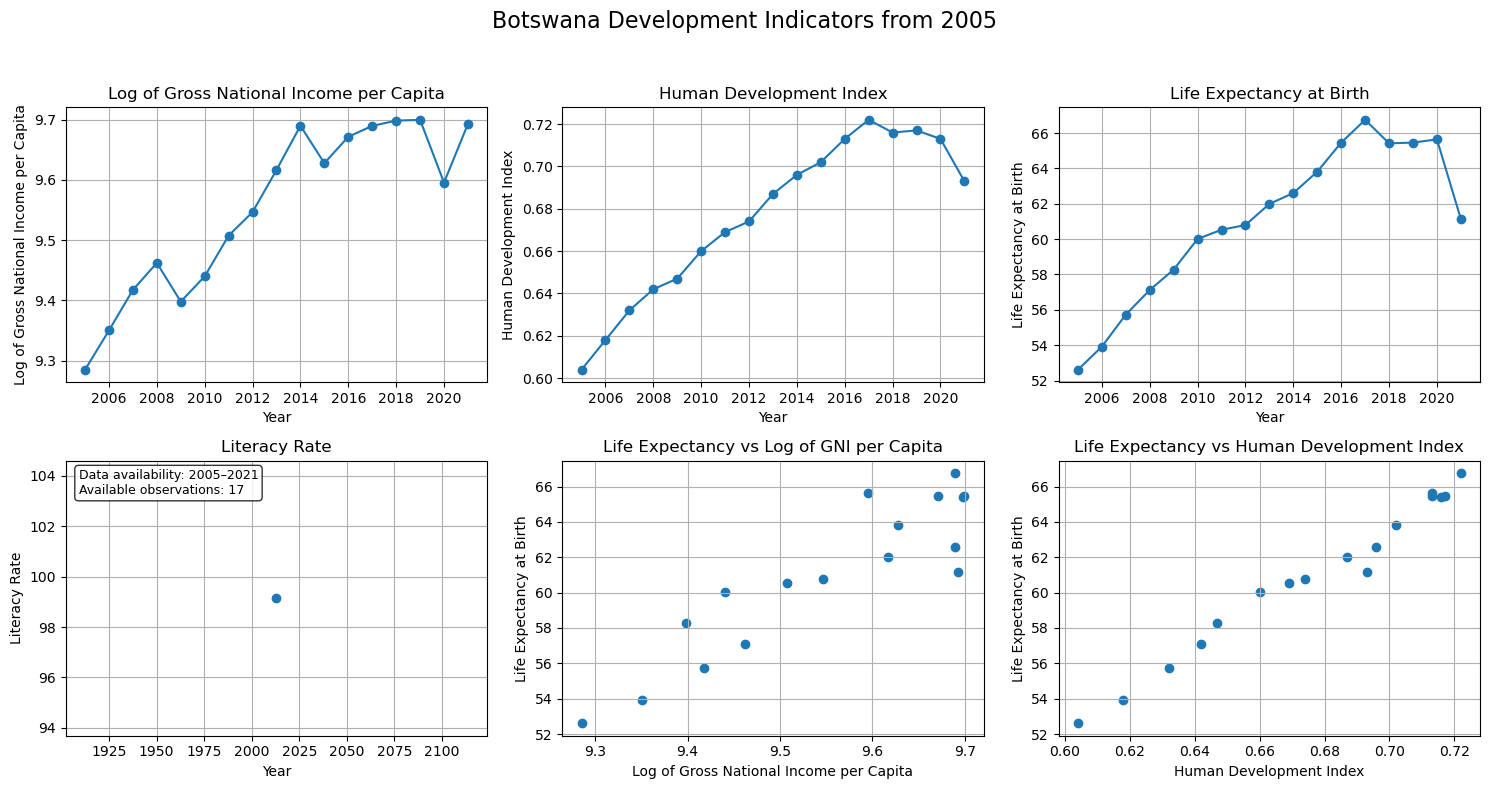

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize the DataFrame
plot_df = botswana_subset.copy()

# Indicators for the time-series plots
plot_indicators = [
    "log_gni_per_capita",
    "human_development_index",
    "life_expectancy_by_birth",
    "literacy_rate_data"
]

# Graph titles and y-axis labels
plot_labels = {
    "log_gni_per_capita":
    "Log of Gross National Income per Capita",
    "human_development_index":
    "Human Development Index",
    "life_expectancy_by_birth":
    "Life Expectancy at Birth",
    "literacy_rate_data":
    "Literacy Rate"
}

# Create a 2 × 3 grid
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

# Convert the axes array into a one-dimensional array
axes = axes.flatten()

# Plot the first four indicators against Year
for ax, indicator in zip(axes[:4], plot_indicators):

    ax.plot(plot_df["Year"], plot_df[indicator], marker="o")
    ax.set_title(plot_labels[indicator])
    ax.set_xlabel("Year")
    ax.set_ylabel(plot_labels[indicator])
    ax.grid(True)

    # Add data-availability annotation
    # only to the literacy-rate graph
    if (indicator == "literacy_rate_data" and not plot_df.empty):
        literacy_start_year = int(plot_df["Year"].min())

        literacy_end_year = int(plot_df["Year"].max())

        literacy_observations = len(plot_df)

        ax.text(0.03, 0.97,
            (
                f"Data availability: "
                f"{literacy_start_year}–"
                f"{literacy_end_year}\n"
                f"Available observations: "
                f"{literacy_observations}"
            ),
            transform=ax.transAxes,
            verticalalignment="top",
            horizontalalignment="left",
            fontsize=9,
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.8
            }
        )

# 5th graph: Life Expectancy vs Log of GNI per Capita
relationship_df_1 = botswana_subset.dropna(
    subset=[
        "log_gni_per_capita",
        "life_expectancy_by_birth"
    ]
)

axes[4].scatter(relationship_df_1["log_gni_per_capita"], relationship_df_1["life_expectancy_by_birth"])
axes[4].set_title("Life Expectancy vs Log of GNI per Capita")
axes[4].set_xlabel("Log of Gross National Income per Capita")
axes[4].set_ylabel("Life Expectancy at Birth")
axes[4].grid(True)

# 6th graph: Life Expectancy vs Human Development Index
relationship_df_2 = botswana_subset.dropna(
    subset=[
        "human_development_index",
        "life_expectancy_by_birth"
    ]
)

axes[5].scatter(relationship_df_2["human_development_index"], relationship_df_2["life_expectancy_by_birth"])
axes[5].set_title("Life Expectancy vs Human Development Index")
axes[5].set_xlabel("Human Development Index")
axes[5].set_ylabel("Life Expectancy at Birth")
axes[5].grid(True)

# Add the main figure title
fig.suptitle("Botswana Development Indicators from 2005", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

## 7.0 A visual representation of Life Expectancy across SADC
7.1 Red represent the lowest Life expectancy in SADC
<br>7.2 Dark Green represent the highest Life Expectancy in SADC<br>

In [33]:
import pandas as pd

# Load the CSV file
df1 = pd.read_csv("consolidated_indicators.csv")
# Preview
# df1.head() 

In [34]:
import pandas as pd

# Load the CSV file
df2 = pd.read_csv("southern_africa_data.csv")

# Rename the country column
df2 = df2.rename(columns={"COUNTRY": "Country"})

# Standardise country names
country_name_mapping = {
    "Democratic Republic of Congo": "Democratic Republic of the Congo",
    "Swaziland": "Eswatini",
}

df2["Country"] = (df2["Country"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace(country_name_mapping)
)

# Preview and check the updated country names
# print(df2["Country"].unique())

In [35]:
# Merge df1 and df2 using the Country column
merged_df = pd.merge(df1, df2, on="Country", how="left")

# Preview to check if merged and save
display(merged_df.head())
merged_df.to_csv("merged_geo_socio_data.csv", index=False)

,Country,Year,gross_national_income_per_capital,human_development_index,life_expectancy_by_birth,literacy_rate_data,merged_geo_socio_data,merged_southern_africa_data,geometry
0,Afghanistan,1979,NaN,NaN,NaN,11.1428,NaN,NaN,NaN
1,Afghanistan,1990,2684.550019,0.273,45.9672,NaN,45.9672,45.9672,NaN
2,Afghanistan,1991,2276.289409,0.279,46.6631,NaN,46.6631,46.6631,NaN
3,Afghanistan,1992,2059.868084,0.287,47.5955,NaN,47.5955,47.5955,NaN
4,Afghanistan,1993,1525.533426,0.297,51.4664,NaN,51.4664,51.4664,NaN


#### 7.1 Plotting the color map (cmap) of SADC for Life Expectancy

In [36]:
%pip install geopandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


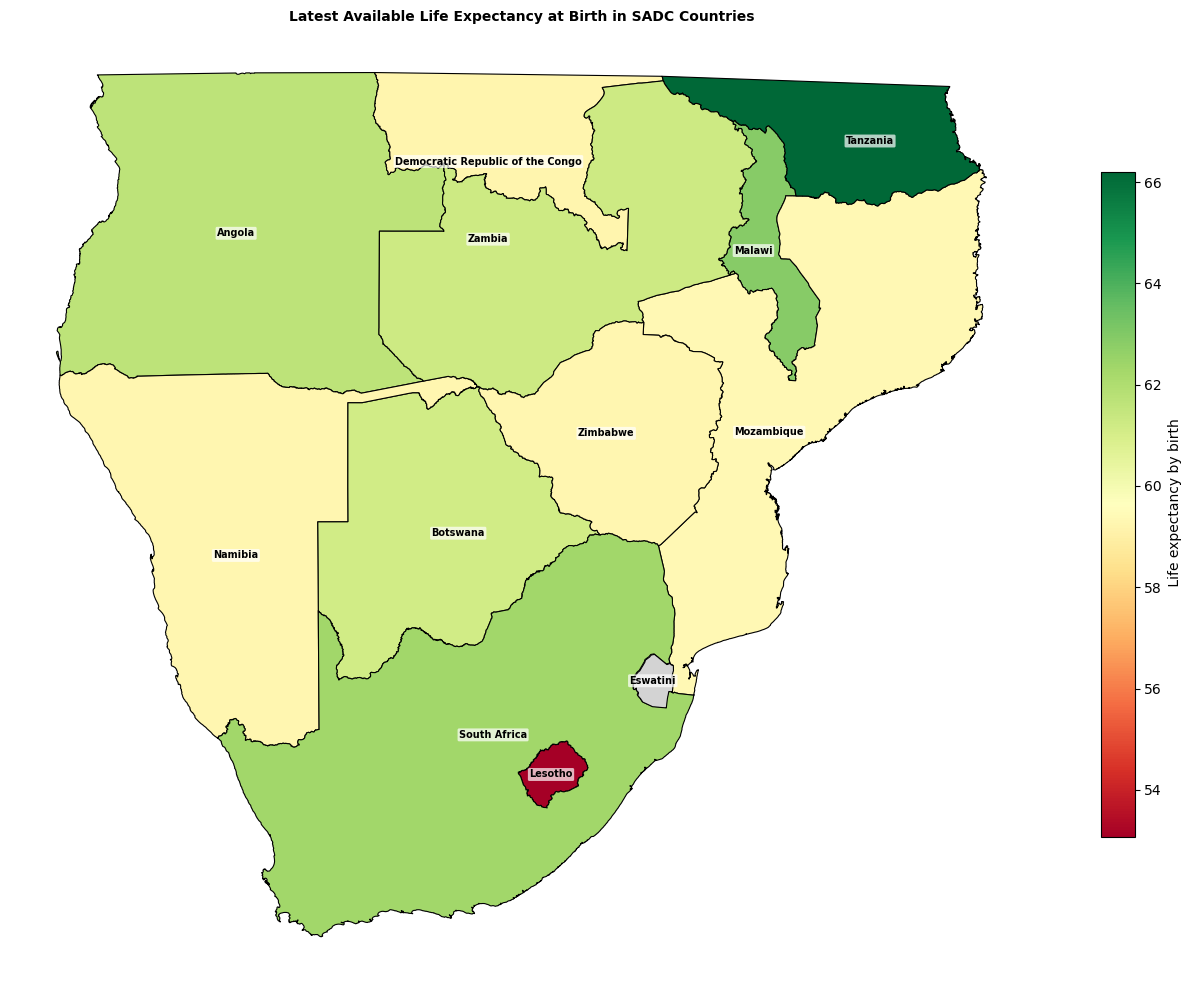

SADC countries absent from the CSV: []

Countries without valid geometry:
['Comoros', 'Madagascar', 'Mauritius', 'Seychelles']

Countries without life-expectancy data:
 Country
Eswatini


In [40]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry.base import BaseGeometry

# SADC member states
sadc_countries = [
    "Angola",
    "Botswana",
    "Comoros",
    "Democratic Republic of the Congo",
    "Eswatini",
    "Lesotho",
    "Madagascar",
    "Malawi",
    "Mauritius",
    "Mozambique",
    "Namibia",
    "Seychelles",
    "South Africa",
    "Tanzania",
    "Zambia",
    "Zimbabwe",
]

# Indicator settings
indicator = "life_expectancy_by_birth"
indicator_label = f" {life_indicator.replace('_', ' ').capitalize()}"

# Work on a copy
df = merged_df.copy()

# Clean country names
df["Country"] = (df["Country"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert indicator and year columns to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df[indicator] = pd.to_numeric(df[indicator], errors="coerce")


# Convert WKT strings into Shapely geometry objects
def convert_geometry(value):
    if isinstance(value, BaseGeometry):
        geometry = value
    elif value is None or pd.isna(value):
        return None
    else:
        try:
            geometry = wkt.loads(str(value).strip())
        except Exception:
            return None

    # Attempt to repair invalid geometries
    if not geometry.is_valid:
        geometry = geometry.buffer(0)

    return geometry if not geometry.is_empty else None


df["geometry"] = df["geometry"].apply(convert_geometry)

# Create GeoDataFrame
merged_gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=None,)

# Filter for SADC countries
sadc_gdf = merged_gdf.loc[merged_gdf["Country"].isin(sadc_countries)].copy()

# Combine all polygon parts into one multipart geometry per country
sadc_boundaries = (sadc_gdf
    .loc[sadc_gdf["geometry"].notna(), ["Country", "geometry"],]
    .drop_duplicates()
    .dissolve(by="Country", as_index=False)
)

# Select latest non-null life-expectancy observation per country
latest_life_expectancy = (
    sadc_gdf.loc[
        sadc_gdf[indicator].notna(),
        ["Country", "Year", indicator],
    ]
    .drop_duplicates()
    .sort_values(["Country", "Year"])
    .drop_duplicates(subset="Country", keep="last")
)

# Merge boundaries with the latest indicator values
sadc_life_expectancy_map = gpd.GeoDataFrame(
    sadc_boundaries.merge(
        latest_life_expectancy,
        on="Country",
        how="left",
    ),
    geometry="geometry",
    crs=merged_gdf.crs,
)

# Select the latest available life-expectancy value per country
latest_life_expectancy = (
    sadc_gdf.loc[
        sadc_gdf[indicator].notna(),
        ["Country", "Year", indicator],
    ]
    .sort_values(["Country", "Year"])
    .drop_duplicates(subset="Country", keep="last")
)

# Merge country boundaries with indicator values
sadc_life_expectancy_map = gpd.GeoDataFrame(
    sadc_boundaries.merge(latest_life_expectancy, on="Country", how="left"),
    geometry="geometry",
    crs=merged_gdf.crs,
)

# Plot the choropleth map
fig, ax = plt.subplots(figsize=(14, 10))

sadc_life_expectancy_map.plot(
    column=indicator,
    cmap="RdYlGn",
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    # missing_kwds controls how countries with missing (NaN) life-expectancy data appear on the map
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "label": "No life-expectancy data",
    },
    legend_kwds={
        "label": indicator_label,
        "shrink": 0.7,
    },
    ax=ax,
)

# Annotate each country once
for _, row in sadc_life_expectancy_map.iterrows():
    geometry = row["geometry"]

    if geometry is None or geometry.is_empty:
        continue

    # For multipart countries, place the label on the largest polygon
    if geometry.geom_type == "MultiPolygon":
        label_geometry = max(
            geometry.geoms,
            key=lambda polygon: polygon.area,
        )
    else:
        label_geometry = geometry

    label_point = label_geometry.representative_point()

    ax.annotate(
        text=row["Country"],
        xy=(label_point.x, label_point.y),
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="black",
        bbox={
            "boxstyle": "round,pad=0.15",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.70,
        },
    )
        
ax.set_title("Latest Available Life Expectancy at Birth in SADC Countries", fontsize=10, fontweight="bold")

ax.set_axis_off()
plt.tight_layout()

# Save and display the map
fig.savefig("sadc_life_expectancy_map.png", dpi=300, bbox_inches="tight")

plt.show()

# Validation checks
countries_in_csv = set(sadc_gdf["Country"].dropna())

print("SADC countries absent from the CSV:", 
      sorted(
          set(sadc_countries) - countries_in_csv
      )
     )

print("\nCountries without valid geometry:")
print(
    sorted(
        set(sadc_countries)
        - set(sadc_boundaries["Country"].dropna())
    )
)

print("\nCountries without life-expectancy data:")
print(
    sadc_life_expectancy_map.loc[
        sadc_life_expectancy_map[indicator].isna(),
        ["Country"],
    ].to_string(index=False)
)

## 8. Declarations and References

#### 8.1 Declaration(s)

Artificial intelligence tools, specifically ChatGPT and Copilot, were used to assist with the report’s structure, improve conciseness, and shorten the content to meet the 2,500-word limit. ChatGPT was also used to assist with code refactoring and organisation.

#### 8.2 Reference(s)

1.	Tulchinsky, T. H., & Varavikova, E. A. (2014). Measuring, monitoring, and evaluating the health of a population. In The New Public Health (3rd ed., pp. 91–147). Elsevier. https://doi.org/10.1016/B978-0-12-415766-8.00003-3

2.	Pavía, J. M., Lledó, J., & Roig, R. (2026). The cost of inequality: Income and life expectancy at birth in Spain. Health Policy, 169, 105616. https://doi.org/10.1016/j.healthpol.2026.105616

3.	Jaba, E., Balan, C. B., & Robu, I.-B. (2014). The relationship between life expectancy at birth and health expenditures estimated by a cross-country and time-series analysis. Procedia Economics and Finance, 15, 108–114. https://doi.org/10.1016/S2212-5671(14)00454-7

4.	Maiolo, V., Keilman, N., & Gjertsen, F. (2023). Sex-differences in life expectancy at birth: A descriptive analysis of the contributions of age and causes of death to the gap in Norway, 1881–2011. Social Sciences & Humanities Open, 8, 100450. https://doi.org/10.1016/j.ssaho.2023.100450

5.	Welsh, C. E., Matthews, F. E., & Jagger, C. (2021). Trends in life expectancy and healthy life years at birth and age 65 in the UK, 2008–2016, and other countries of the EU28: An observational cross-sectional study. The Lancet Regional Health – Europe, 2, 100023. https://doi.org/10.1016/j.lanepe.2020.100023

6.  SASSCAL. (n.d.). Southern Africa – Countries [Geospatial dataset]. SASSCAL Data and Information Portal. Retrieved August 19, 2026, from https://data.sasscal.org/metadata/view.php?view=geodata&id=168


In [45]:
%%js

// Run this cell to update your word count.

function wordcount() {
    let wordCount = 0
    let extraCount = 0
    let mainBody = true

    let cells = Jupyter.notebook.get_cells()
    cells.forEach((cell) => {
        if (cell.cell_type == 'markdown') {
            let text = cell.get_text()
            // Stop counting as main body when get to References or Appendices.
            if (text.startsWith('## References') ||
                text.startsWith('## Appendices')) {
                mainBody = false
            }
            if (text.startsWith('## Word Count')) {
                text = ''
            }
            if (text) {
                let words = text.toLowerCase().match(/\b[a-z\d]+\b/g)
                if (words) {
                    let cellCount = words.length
                    if (mainBody) {
                        wordCount += cellCount
                    } else {
                        extraCount += cellCount
                    }
                }
            }
        }
    })
    return [wordCount, extraCount]
}

let wc = wordcount()
element.append(`Main word count: ${wc[0]} (References and appendices word count: ${wc[1]})`)

<IPython.core.display.Javascript object>